<a href="https://colab.research.google.com/github/SANGRAMLEMBE/MTech/blob/main/Deep_Neural_Network/Practical/assignment/03_first_cnn_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3: Building Your First CNN

**Course:** 21CSE558T - Deep Neural Network Architectures  
**Module 4:** CNNs - Practical Session  
**Date:** Saturday, November 1, 2025  
**Duration:** 40 minutes  
**Objective:** Build, train, and understand a complete CNN on Fashion-MNIST

---

## What We'll Build

**A simple but effective CNN:**
```
Input (28×28×1)
    ↓
Conv2D(32 filters, 3×3) + ReLU
    ↓
MaxPooling(2×2)
    ↓
Conv2D(64 filters, 3×3) + ReLU
    ↓
MaxPooling(2×2)
    ↓
Flatten
    ↓
Dense(128) + ReLU
    ↓
Dense(10) + Softmax
```

**Expected accuracy:** ~90% (much better than MLP!)

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow version: 2.19.0
✅ GPU available: True


---

## Part 1: Load and Prepare Data

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 60,000
Test samples: 10,000
Image shape: (28, 28)
Number of classes: 10


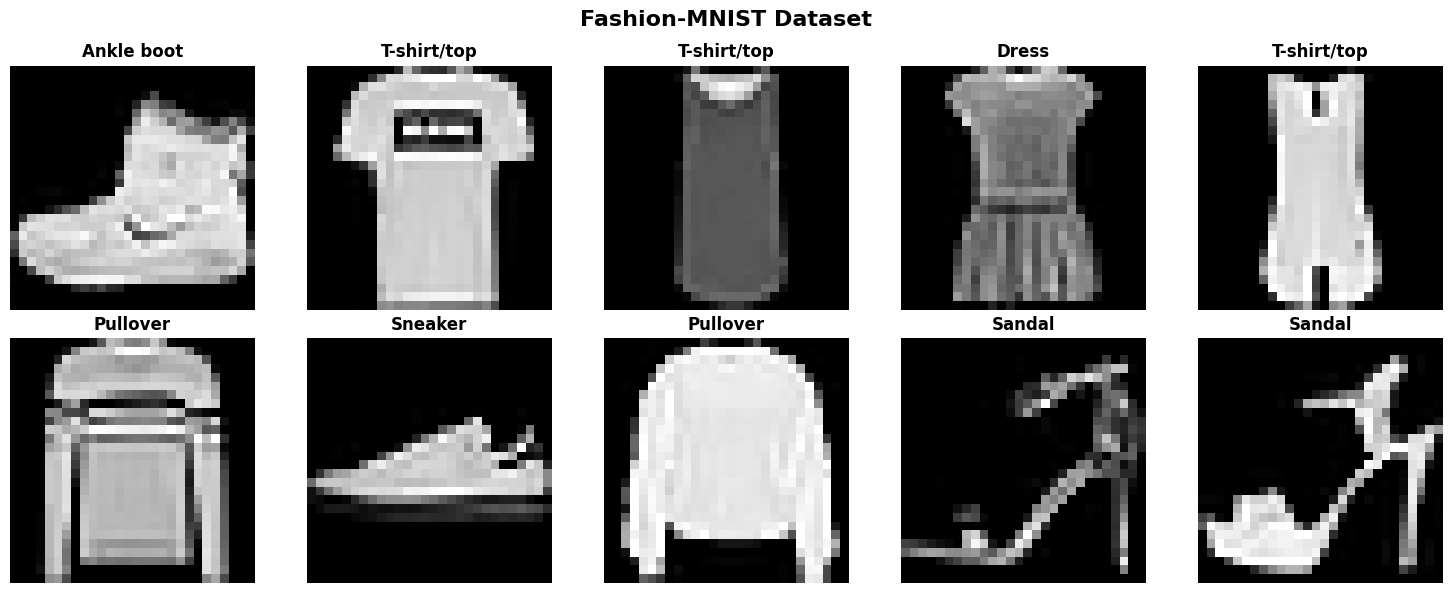

In [2]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples: {x_train.shape[0]:,}")
print(f"Test samples: {x_test.shape[0]:,}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"Number of classes: {len(class_names)}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'{class_names[y_train[i]]}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Fashion-MNIST Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preprocessing

In [3]:
# 1. Reshape to add channel dimension (H, W, C)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2. Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\n✅ Preprocessing complete!")
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train_cat.shape}")
print(f"Pixel value range: [{x_train.min():.2f}, {x_train.max():.2f}]")


✅ Preprocessing complete!
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000, 10)
Pixel value range: [0.00, 1.00]


---

## Part 2: Build CNN Architecture

In [4]:
# Build CNN model
model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),

    # Fully connected layers
    Flatten(name='flatten'),
    Dense(128, activation='relu', name='fc1'),
    Dense(10, activation='softmax', name='output')
], name='SimpleCNN')

# Display architecture
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n📊 Total parameters: {total_params:,}")

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


📊 Total parameters: 225,034


### Understanding the Architecture

**Layer-by-layer breakdown:**

1. **Conv2D(32, 3×3):** 32 filters of size 3×3
   - Input: 28×28×1
   - Output: 26×26×32 (each filter creates one feature map)
   - Parameters: (3×3×1 + 1 bias) × 32 = 320

2. **MaxPooling(2×2):** Downsample by taking maximum in 2×2 windows
   - Input: 26×26×32
   - Output: 13×13×32
   - Parameters: 0 (no learning)

3. **Conv2D(64, 3×3):** 64 filters
   - Input: 13×13×32
   - Output: 11×11×64
   - Parameters: (3×3×32 + 1) × 64 = 18,496

4. **MaxPooling(2×2):**
   - Input: 11×11×64
   - Output: 5×5×64

5. **Flatten:** Convert to 1D vector
   - Input: 5×5×64
   - Output: 1600

6. **Dense(128):** Fully connected
   - Parameters: 1600×128 + 128 = 204,928

7. **Dense(10):** Output layer
   - Parameters: 128×10 + 10 = 1,290

---

## Part 3: Compile Model

In [5]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
print("\nConfiguration:")
print(f"  Optimizer: Adam")
print(f"  Loss: Categorical Crossentropy")
print(f"  Metrics: Accuracy")

✅ Model compiled!

Configuration:
  Optimizer: Adam
  Loss: Categorical Crossentropy
  Metrics: Accuracy


---

## Part 4: Train Model

In [6]:
# Train model
print("🚀 Starting training...\n")

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Training complete!")

🚀 Starting training...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7262 - loss: 0.7994 - val_accuracy: 0.8625 - val_loss: 0.3787
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8717 - loss: 0.3592 - val_accuracy: 0.8803 - val_loss: 0.3306
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8888 - loss: 0.3092 - val_accuracy: 0.8895 - val_loss: 0.3016
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8955 - loss: 0.2829 - val_accuracy: 0.8987 - val_loss: 0.2781
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9074 - loss: 0.2499 - val_accuracy: 0.9028 - val_loss: 0.2691
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9133 - loss: 0.2333 - val_accuracy: 0.9035 - val_loss: 0.2601
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9227 - loss: 0.2129 - val_accuracy: 0.9068 - val_loss: 0.2589
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9263 - loss: 

---

## Part 5: Visualize Training History

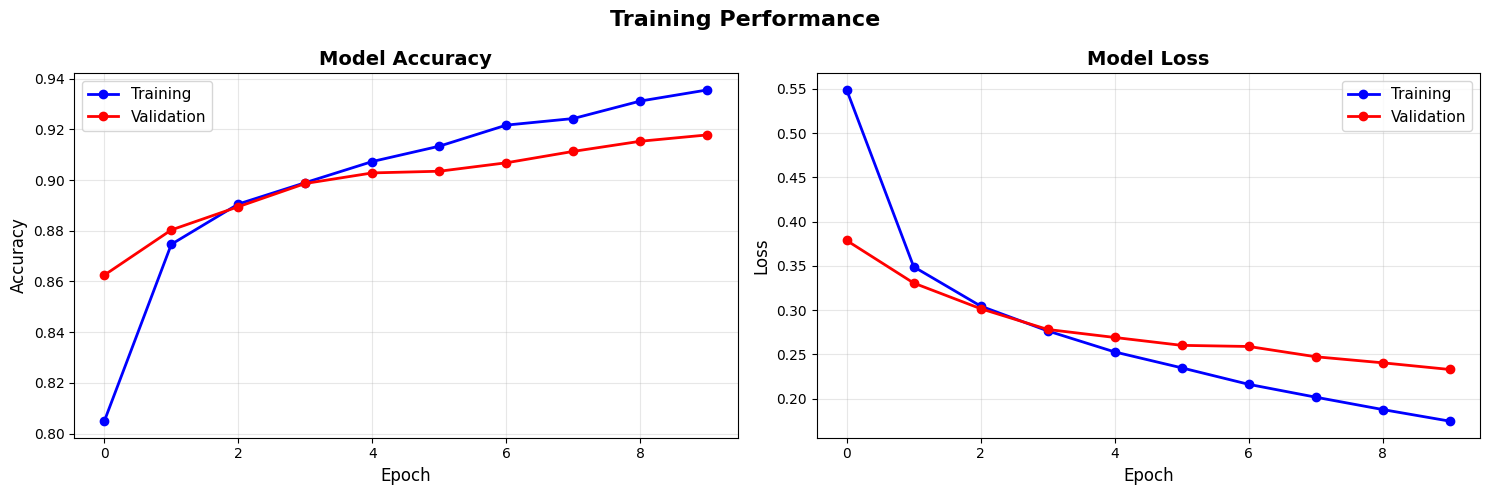


📊 Final Results:
Training Accuracy:   93.56%
Validation Accuracy: 91.78%


In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], 'b-o', label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-o', label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], 'b-o', label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-o', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n📊 Final Results:")
print(f"Training Accuracy:   {final_train_acc:.2%}")
print(f"Validation Accuracy: {final_val_acc:.2%}")

---

## Part 6: Evaluate on Test Set

In [8]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"\n🎯 Test Set Performance:")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2%}")

# Make predictions
predictions = model.predict(x_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Calculate per-class accuracy
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n📋 Classification Report:\n")
print(classification_report(y_test, predicted_classes, target_names=class_names))


🎯 Test Set Performance:
Test Loss:     0.2525
Test Accuracy: 91.04%

📋 Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.90      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.82      0.89      0.85      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.87      0.85      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.78      0.70      0.74      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



---

## Part 7: Confusion Matrix

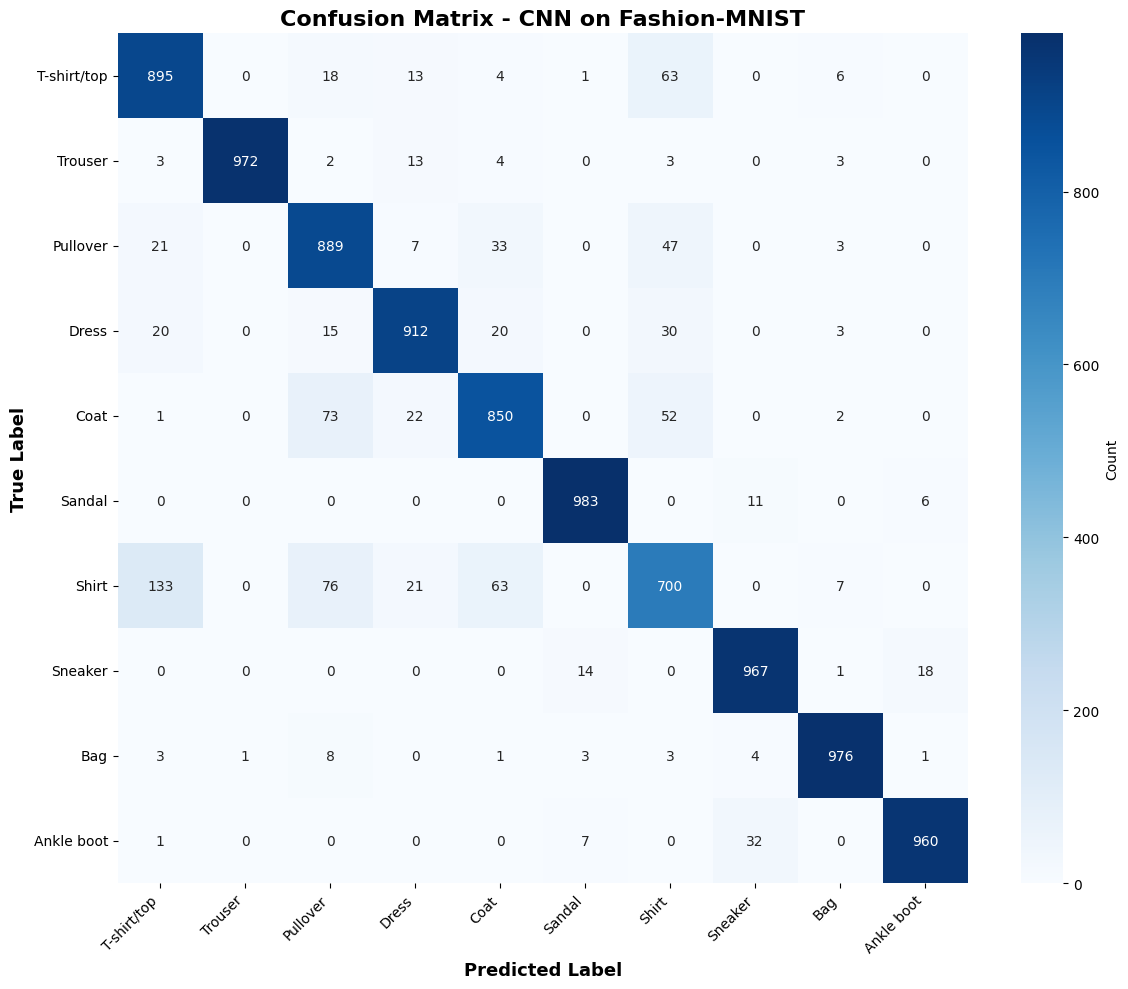


💡 Confusion Matrix Insights:
  • Diagonal = Correct predictions
  • Off-diagonal = Misclassifications
  • Look for patterns: Which classes confuse the model?


In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix - CNN on Fashion-MNIST', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Confusion Matrix Insights:")
print("  • Diagonal = Correct predictions")
print("  • Off-diagonal = Misclassifications")
print("  • Look for patterns: Which classes confuse the model?")

---

## Part 8: Visualize Predictions

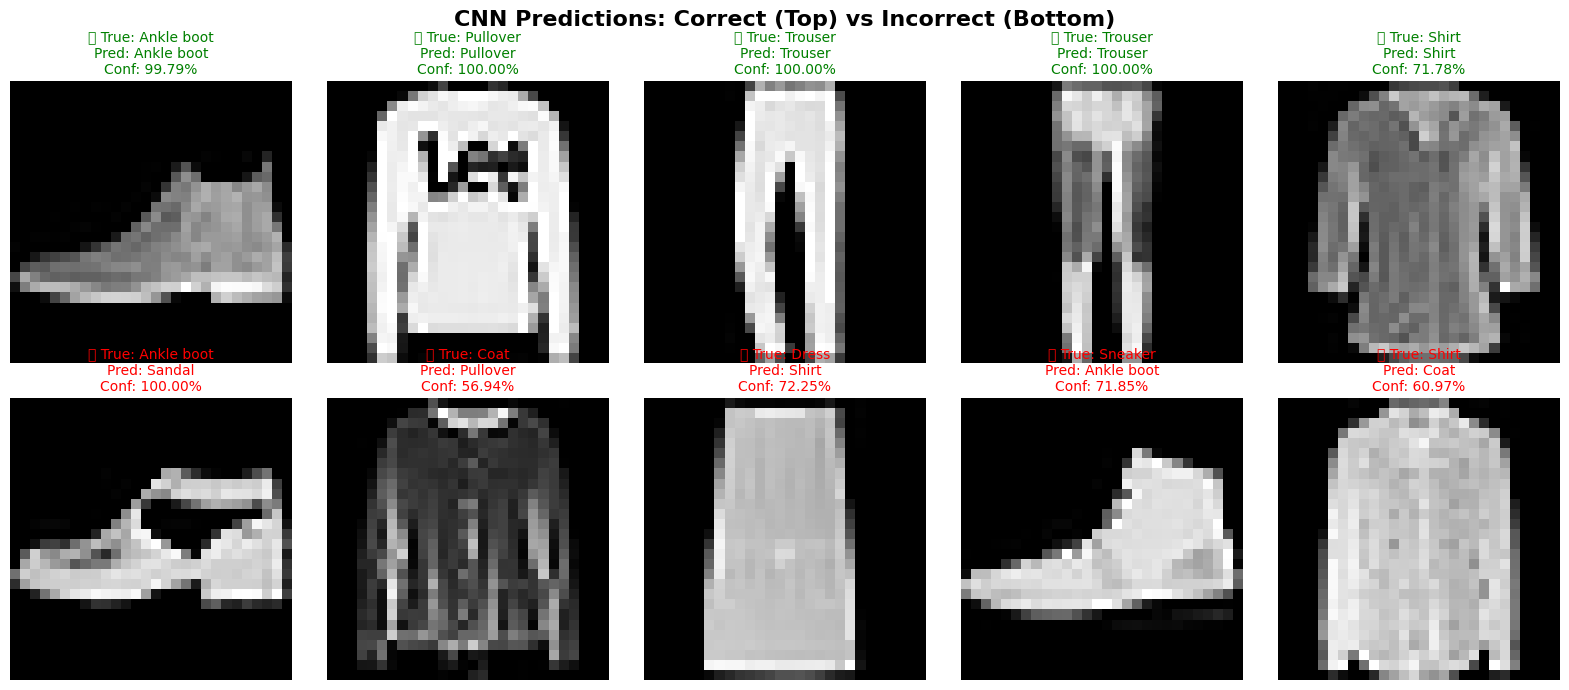

In [10]:
# Show correct and incorrect predictions
correct_idx = np.where(predicted_classes == y_test)[0]
incorrect_idx = np.where(predicted_classes != y_test)[0]

# Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Correct predictions (top row)
for i, ax in enumerate(axes[0]):
    idx = correct_idx[i]
    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'✅ True: {class_names[y_test[idx]]}\nPred: {class_names[predicted_classes[idx]]}\nConf: {predictions[idx][predicted_classes[idx]]:.2%}',
                fontsize=10, color='green')
    ax.axis('off')

# Incorrect predictions (bottom row)
for i, ax in enumerate(axes[1]):
    idx = incorrect_idx[i]
    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'❌ True: {class_names[y_test[idx]]}\nPred: {class_names[predicted_classes[idx]]}\nConf: {predictions[idx][predicted_classes[idx]]:.2%}',
                fontsize=10, color='red')
    ax.axis('off')

plt.suptitle('CNN Predictions: Correct (Top) vs Incorrect (Bottom)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Part 9: Compare with MLP (Baseline)

🔄 Training MLP baseline...



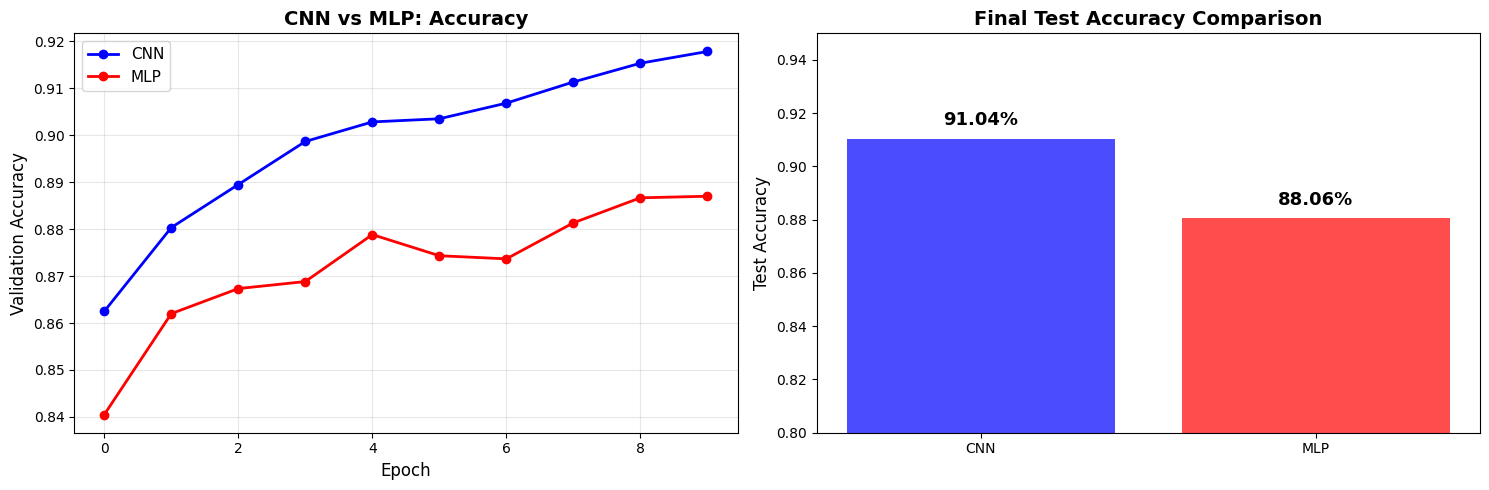


📊 Comparison:
CNN Test Accuracy: 91.04%
MLP Test Accuracy: 88.06%
Improvement:       +2.98%

💡 CNN Parameters: 225,034
💡 MLP Parameters: 109,386

✅ CNN is better with FEWER parameters!


In [11]:
# Build simple MLP for comparison
mlp_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
], name='SimpleMLP')

mlp_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("🔄 Training MLP baseline...\n")
mlp_history = mlp_model.fit(x_train, y_train_cat,
                            batch_size=128,
                            epochs=10,
                            validation_split=0.1,
                            verbose=0)

# Evaluate
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test, y_test_cat, verbose=0)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].plot(history.history['val_accuracy'], 'b-o', label='CNN', linewidth=2)
axes[0].plot(mlp_history.history['val_accuracy'], 'r-o', label='MLP', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].set_title('CNN vs MLP: Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Final test accuracy bar chart
axes[1].bar(['CNN', 'MLP'], [test_acc, mlp_test_acc], color=['blue', 'red'], alpha=0.7)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([0.8, 0.95])
for i, v in enumerate([test_acc, mlp_test_acc]):
    axes[1].text(i, v + 0.005, f'{v:.2%}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Comparison:")
print(f"CNN Test Accuracy: {test_acc:.2%}")
print(f"MLP Test Accuracy: {mlp_test_acc:.2%}")
print(f"Improvement:       +{(test_acc - mlp_test_acc):.2%}")
print(f"\n💡 CNN Parameters: {model.count_params():,}")
print(f"💡 MLP Parameters: {mlp_model.count_params():,}")
print(f"\n✅ CNN is better with FEWER parameters!")

---

## Summary: Key Takeaways 🎯

### What You Built:

1. **✅ Complete CNN** with 2 conv blocks + 2 dense layers
2. **✅ ~90% accuracy** on Fashion-MNIST
3. **✅ Better than MLP** with fewer parameters

### Why CNN Works Better:

- **Spatial structure:** Conv layers preserve 2D relationships
- **Local patterns:** Filters detect edges, textures, shapes
- **Translation invariance:** Same filter slides across entire image
- **Parameter sharing:** Same weights used at all positions
- **Hierarchical features:** Low-level → High-level patterns

### Architecture Insights:

1. **Conv → Pool pattern:** Standard building block
2. **Increasing filters:** 32 → 64 (more complex patterns in deeper layers)
3. **Decreasing spatial size:** 28×28 → 13×13 → 5×5 (via pooling)
4. **MaxPooling:** Downsamples and adds translation invariance
5. **ReLU activation:** Enables learning complex patterns

---

## Practice Exercises 📝

**Before Notebook 4:**

1. **Experiment:** Change the number of filters in conv layers. What happens?

2. **Experiment:** Add a third conv block. Does accuracy improve?

3. **Calculate:** What's the output size after Conv2D(64, 5×5) on a 28×28 input?

4. **Challenge:** Can you achieve >91% accuracy by modifying the architecture?

---

## Next: Notebook 4 - Architecture Experiments 🔬

**Your homework!** Systematically experiment with different architectures.

---

*⏱️ Time spent: ~40 minutes*  
*💪 Difficulty: Intermediate*  
*🎓 Mastery: Complete CNN implementation*

In [13]:
# Experiment 2: Add a third convolutional block

# Build CNN model with a third conv block
model_exp2 = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1_exp2'),
    MaxPooling2D((2, 2), name='pool1_exp2'),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', name='conv2_exp2'),
    MaxPooling2D((2, 2), name='pool2_exp2'),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu', name='conv3_exp2'),
    MaxPooling2D((2, 2), name='pool3_exp2'),

    # Fully connected layers
    Flatten(name='flatten_exp2'),
    Dense(128, activation='relu', name='fc1_exp2'),
    Dense(10, activation='softmax', name='output_exp2')
], name='CNN_Exp2_ThirdBlock')

# Compile model
model_exp2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_exp2.summary()

print("\n🚀 Starting training for Experiment 2 (third conv block)...\n")

history_exp2 = model_exp2.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Training complete for Experiment 2!")

# Evaluate on test data
test_loss_exp2, test_acc_exp2 = model_exp2.evaluate(x_test, y_test_cat, verbose=0)

print(f"\n🎯 Test Set Performance for Experiment 2:")
print(f"Test Loss:     {test_loss_exp2:.4f}")
print(f"Test Accuracy: {test_acc_exp2:.2%}")

Model: "CNN_Exp2_ThirdBlock"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_exp2 (Conv2D)             │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_exp2 (MaxPooling2D)       │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_exp2 (Conv2D)             │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2_exp2 (MaxPooling2D)       │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_exp2 (Conv2D)             │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3_exp2 (MaxPooling2D)       │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_exp2 (Flatten)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_exp2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_exp2 (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 2 (third conv block)...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6398 - loss: 1.0168 - val_accuracy: 0.8170 - val_loss: 0.5029
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8250 - loss: 0.4884 - val_accuracy: 0.8432 - val_loss: 0.4225
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8520 - loss: 0.4050 - val_accuracy: 0.8610 - val_loss: 0.3756
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8681 - loss: 0.3578 - val_accuracy: 0.8727 - val_loss: 0.3559
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8792 - loss: 0.3369 - val_accuracy: 0.8700 - val_loss: 0.3624
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8876 - loss: 0.3042 - val_accuracy: 0.8783 - val_loss: 0.3327
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8940 - loss: 0.2867 - val_accuracy: 0.8842 - val_loss: 0.3218
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s

In [12]:
# Experiment 1: Change the number of filters

# Build CNN model with fewer filters
model_exp1 = Sequential([
    # First convolutional block (fewer filters)
    Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1_exp1'),
    MaxPooling2D((2, 2), name='pool1_exp1'),

    # Second convolutional block (fewer filters)
    Conv2D(32, (3, 3), activation='relu', name='conv2_exp1'),
    MaxPooling2D((2, 2), name='pool2_exp1'),

    # Fully connected layers
    Flatten(name='flatten_exp1'),
    Dense(64, activation='relu', name='fc1_exp1'),
    Dense(10, activation='softmax', name='output_exp1')
], name='CNN_Exp1_FewerFilters')

# Compile model
model_exp1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_exp1.summary()

print("\n🚀 Starting training for Experiment 1 (fewer filters)...\n")

history_exp1 = model_exp1.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

print("\n✅ Training complete for Experiment 1!")

# Evaluate on test data
test_loss_exp1, test_acc_exp1 = model_exp1.evaluate(x_test, y_test_cat, verbose=0)

print(f"\n🎯 Test Set Performance for Experiment 1:")
print(f"Test Loss:     {test_loss_exp1:.4f}")
print(f"Test Accuracy: {test_acc_exp1:.2%}")

Model: "CNN_Exp1_FewerFilters"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_exp1 (Conv2D)             │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_exp1 (MaxPooling2D)       │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_exp1 (Conv2D)             │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2_exp1 (MaxPooling2D)       │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_exp1 (Flatten)          │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_exp1 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_exp1 (Dense)             │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 1 (fewer filters)...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6922 - loss: 0.9264 - val_accuracy: 0.8468 - val_loss: 0.4406
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8487 - loss: 0.4284 - val_accuracy: 0.8675 - val_loss: 0.3747
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8714 - loss: 0.3592 - val_accuracy: 0.8765 - val_loss: 0.3460
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8814 - loss: 0.3334 - val_accuracy: 0.8778 - val_loss: 0.3388
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8935 - loss: 0.3032 - val_accuracy: 0.8840 - val_loss: 0.3159
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8979 - loss: 0.2834 - val_accuracy: 0.8910 - val_loss: 0.3102
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9042 - loss: 0.2705 - val_accuracy: 0.9017 - val_loss: 0.2792
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5m